In [1]:
from pathlib import Path

# Project data folder
DATA_DIR = Path("../data/raw")

# Map each federated client to CICIDS2017 days
client_files = {
    "Hospital": [
        "Monday-WorkingHours.pcap_ISCX.csv",
        "Tuesday-WorkingHours.pcap_ISCX.csv"
    ],

    "Bank": [
        "Wednesday-workingHours.pcap_ISCX.csv"
    ],

    "University": [
        "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
        "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"
    ],

    "ISP": [
        "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
        "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
        "Friday-WorkingHours-Morning.pcap_ISCX.csv"
    ]
}

# Check that every file exists
for client, files in client_files.items():
    print(f"\n{client}:")
    
    for file in files:
        path = DATA_DIR / file
        
        if path.exists():
            print(f"  ✓ {file}")
        else:
            print(f"  ✗ NOT FOUND: {file}")


Hospital:
  ✓ Monday-WorkingHours.pcap_ISCX.csv
  ✓ Tuesday-WorkingHours.pcap_ISCX.csv

Bank:
  ✓ Wednesday-workingHours.pcap_ISCX.csv

University:
  ✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  ✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv

ISP:
  ✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  ✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  ✓ Friday-WorkingHours-Morning.pcap_ISCX.csv


In [3]:
import pandas as pd
from collections import Counter

# Same label mapping from Day 10
label_mapping = {
    "BENIGN": "BENIGN",
    "DoS Hulk": "DoS",
    "DoS GoldenEye": "DoS",
    "DoS slowloris": "DoS",
    "DoS Slowhttptest": "DoS",
    "DDoS": "DDoS",
    "FTP-Patator": "Brute Force",
    "SSH-Patator": "Brute Force",
    "Web Attack – Brute Force": "Web Attack",
    "Web Attack – XSS": "Web Attack",
    "Web Attack – Sql Injection": "Web Attack",
    "Infiltration": "Infiltration",
    "Bot": "Botnet",
    "PortScan": "Port Scan"
}

# Final 8 project categories
categories = [
    "BENIGN",
    "DoS",
    "DDoS",
    "Brute Force",
    "Web Attack",
    "Infiltration",
    "Botnet",
    "Port Scan"
]

# Store results for every client
client_distribution = {}

for client, files in client_files.items():

    counts = Counter()

    print(f"\nProcessing {client}...")

    for file in files:

        path = DATA_DIR / file

        # Read only the Label column to save RAM
        for chunk in pd.read_csv(
            path,
            usecols=lambda column: column.strip() == "Label",
            chunksize=100000
        ):

            # Remove extra spaces from labels
            labels = chunk.iloc[:, 0].astype(str).str.strip()

            # Convert original labels to project categories
            mapped_labels = labels.map(label_mapping)

            # Count only mapped labels
            mapped_labels = mapped_labels.dropna()

            counts.update(mapped_labels)

    client_distribution[client] = counts

    total = sum(counts.values())

    print(f"Total experimental records: {total}")

    for category in categories:
        count = counts[category]
        percentage = (count / total) * 100 if total > 0 else 0

        print(f"{category:15} {count:10} ({percentage:.4f}%)")


Processing Hospital...
Total experimental records: 975827
BENIGN              961992 (98.5822%)
DoS                      0 (0.0000%)
DDoS                     0 (0.0000%)
Brute Force          13835 (1.4178%)
Web Attack               0 (0.0000%)
Infiltration             0 (0.0000%)
Botnet                   0 (0.0000%)
Port Scan                0 (0.0000%)

Processing Bank...
Total experimental records: 692692
BENIGN              440031 (63.5248%)
DoS                 252661 (36.4752%)
DDoS                     0 (0.0000%)
Brute Force              0 (0.0000%)
Web Attack               0 (0.0000%)
Infiltration             0 (0.0000%)
Botnet                   0 (0.0000%)
Port Scan                0 (0.0000%)

Processing University...
Total experimental records: 456788
BENIGN              456752 (99.9921%)
DoS                      0 (0.0000%)
DDoS                     0 (0.0000%)
Brute Force              0 (0.0000%)
Web Attack               0 (0.0000%)
Infiltration            36 (0.0079%)
Botnet 

In [4]:
# Create a client distribution table

distribution_rows = []

for client, counts in client_distribution.items():

    total = sum(counts.values())

    row = {
        "Client": client,
        "Total Records": total
    }

    for category in categories:
        count = counts[category]
        percentage = (count / total) * 100 if total > 0 else 0

        row[f"{category} (%)"] = round(percentage, 4)

    distribution_rows.append(row)

distribution_df = pd.DataFrame(distribution_rows)

distribution_df

,Client,Total Records,BENIGN (%),DoS (%),DDoS (%),Brute Force (%),Web Attack (%),Infiltration (%),Botnet (%),Port Scan (%)
0,Hospital,975827,98.5822,0.0000,0.0000,1.4178,0.0,0.0000,0.0000,0.0000
1,Bank,692692,63.5248,36.4752,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
2,University,456788,99.9921,0.0000,0.0000,0.0000,0.0,0.0079,0.0000,0.0000
3,ISP,703245,58.9157,0.0000,18.2052,0.0000,0.0,0.0000,0.2796,22.5995


In [5]:
# Save client distribution results

output_path = "../docs/day11_client_distribution.csv"

distribution_df.to_csv(output_path, index=False)

print(f"Client distribution table saved to: {output_path}")

Client distribution table saved to: ../docs/day11_client_distribution.csv


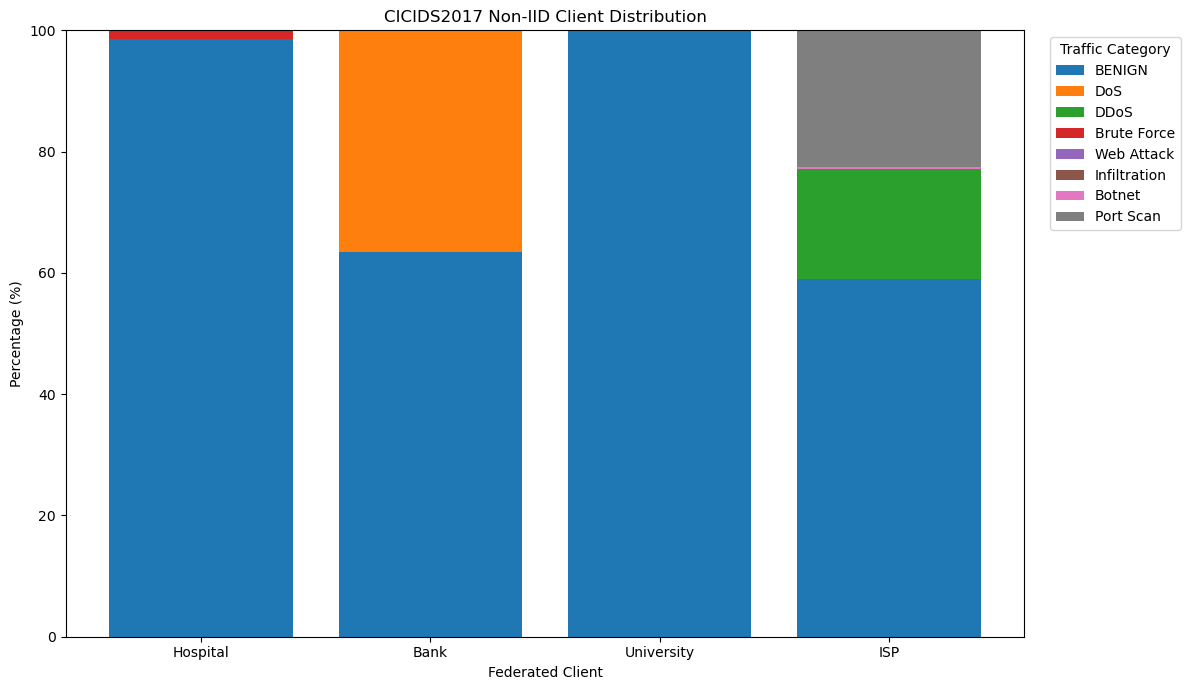

Diagram saved to: ../docs/figures/day11_client_distribution.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Client distribution percentages from our actual results
clients = ["Hospital", "Bank", "University", "ISP"]

data = {
    "BENIGN": [98.5822, 63.5248, 99.9921, 58.9157],
    "DoS": [0, 36.4752, 0, 0],
    "DDoS": [0, 0, 0, 18.2052],
    "Brute Force": [1.4178, 0, 0, 0],
    "Web Attack": [0, 0, 0, 0],
    "Infiltration": [0, 0, 0.0079, 0],
    "Botnet": [0, 0, 0, 0.2796],
    "Port Scan": [0, 0, 0, 22.5995]
}

x = np.arange(len(clients))
bottom = np.zeros(len(clients))

plt.figure(figsize=(12, 7))

for category, values in data.items():
    plt.bar(
        clients,
        values,
        bottom=bottom,
        label=category
    )
    bottom += np.array(values)

plt.title("CICIDS2017 Non-IID Client Distribution")
plt.xlabel("Federated Client")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.legend(
    title="Traffic Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

# Save figure
output_path = "../docs/figures/day11_client_distribution.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Diagram saved to: {output_path}")

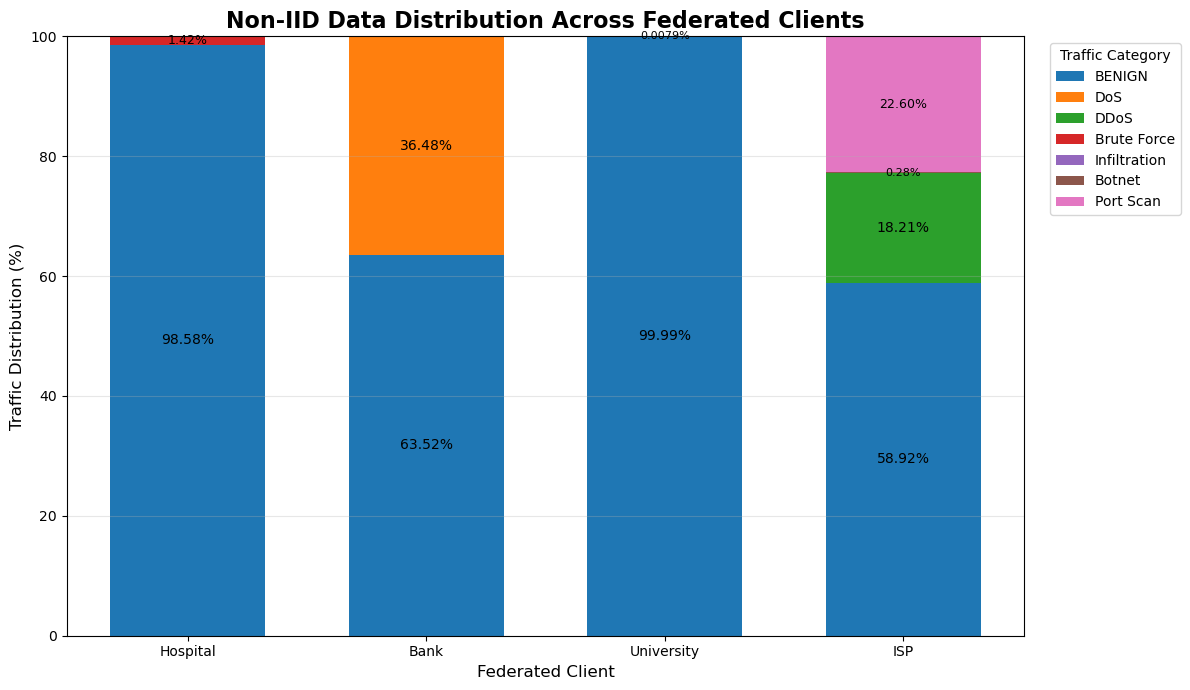

Diagram saved successfully: ../docs/figures/day11_client_distribution.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Actual Day 11 results
clients = ["Hospital", "Bank", "University", "ISP"]

benign = [98.5822, 63.5248, 99.9921, 58.9157]
dos = [0, 36.4752, 0, 0]
ddos = [0, 0, 0, 18.2052]
brute_force = [1.4178, 0, 0, 0]
infiltration = [0, 0, 0.0079, 0]
botnet = [0, 0, 0, 0.2796]
port_scan = [0, 0, 0, 22.5995]

x = np.arange(len(clients))
width = 0.65

plt.figure(figsize=(12, 7))

# Stacked distribution
plt.bar(x, benign, width, label="BENIGN")
plt.bar(x, dos, width, bottom=benign, label="DoS")

bottom_dos = np.array(benign) + np.array(dos)

plt.bar(x, ddos, width, bottom=bottom_dos, label="DDoS")

bottom_ddos = bottom_dos + np.array(ddos)

plt.bar(
    x,
    brute_force,
    width,
    bottom=bottom_ddos,
    label="Brute Force"
)

bottom_brute = bottom_ddos + np.array(brute_force)

plt.bar(
    x,
    infiltration,
    width,
    bottom=bottom_brute,
    label="Infiltration"
)

bottom_infiltration = bottom_brute + np.array(infiltration)

plt.bar(
    x,
    botnet,
    width,
    bottom=bottom_infiltration,
    label="Botnet"
)

bottom_botnet = bottom_infiltration + np.array(botnet)

plt.bar(
    x,
    port_scan,
    width,
    bottom=bottom_botnet,
    label="Port Scan"
)

# Titles and labels
plt.title(
    "Non-IID Data Distribution Across Federated Clients",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Federated Client", fontsize=12)
plt.ylabel("Traffic Distribution (%)", fontsize=12)

plt.xticks(x, clients)
plt.ylim(0, 100)

# Add percentage labels for important non-zero classes
for i in range(len(clients)):

    if benign[i] > 0:
        plt.text(
            i,
            benign[i] / 2,
            f"{benign[i]:.2f}%",
            ha="center",
            va="center",
            fontsize=10
        )

    if dos[i] > 0:
        plt.text(
            i,
            benign[i] + dos[i] / 2,
            f"{dos[i]:.2f}%",
            ha="center",
            va="center",
            fontsize=10
        )

    if ddos[i] > 0:
        plt.text(
            i,
            bottom_dos[i] + ddos[i] / 2,
            f"{ddos[i]:.2f}%",
            ha="center",
            va="center",
            fontsize=10
        )

    if brute_force[i] > 0:
        plt.text(
            i,
            bottom_ddos[i] + brute_force[i] / 2,
            f"{brute_force[i]:.2f}%",
            ha="center",
            va="center",
            fontsize=9
        )

    if infiltration[i] > 0:
        plt.text(
            i,
            bottom_brute[i] + infiltration[i] / 2,
            f"{infiltration[i]:.4f}%",
            ha="center",
            va="center",
            fontsize=8
        )

    if botnet[i] > 0:
        plt.text(
            i,
            bottom_infiltration[i] + botnet[i] / 2,
            f"{botnet[i]:.2f}%",
            ha="center",
            va="center",
            fontsize=8
        )

    if port_scan[i] > 0:
        plt.text(
            i,
            bottom_botnet[i] + port_scan[i] / 2,
            f"{port_scan[i]:.2f}%",
            ha="center",
            va="center",
            fontsize=9
        )

plt.legend(
    title="Traffic Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Save
output_path = "../docs/figures/day11_client_distribution.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Diagram saved successfully: {output_path}")

In [8]:
from collections import Counter

for file in client_files["University"]:
    counts = Counter()
    path = DATA_DIR / file

    for chunk in pd.read_csv(
        path,
        usecols=lambda column: column.strip() == "Label",
        chunksize=100000
    ):
        labels = chunk.iloc[:, 0].astype(str).str.strip()
        counts.update(labels)

    print("\nFILE:", file)
    for label, count in counts.items():
        print(repr(label), "->", count)


FILE: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
'BENIGN' -> 288566
'Infiltration' -> 36

FILE: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
'BENIGN' -> 168186
'Web Attack � Brute Force' -> 1507
'Web Attack � XSS' -> 652
'Web Attack � Sql Injection' -> 21


In [9]:
label_mapping = {
    "BENIGN": "BENIGN",

    "DoS Hulk": "DoS",
    "DoS GoldenEye": "DoS",
    "DoS slowloris": "DoS",
    "DoS Slowhttptest": "DoS",

    "DDoS": "DDoS",

    "FTP-Patator": "Brute Force",
    "SSH-Patator": "Brute Force",

    "Web Attack � Brute Force": "Web Attack",
    "Web Attack � XSS": "Web Attack",
    "Web Attack � Sql Injection": "Web Attack",

    "Infiltration": "Infiltration",

    "Bot": "Botnet",

    "PortScan": "Port Scan"
}

In [10]:
from collections import Counter

categories = [
    "BENIGN",
    "DoS",
    "DDoS",
    "Brute Force",
    "Web Attack",
    "Infiltration",
    "Botnet",
    "Port Scan"
]

client_distribution = {}

for client, files in client_files.items():
    counts = Counter()

    print(f"\nProcessing {client}...")

    for file in files:
        path = DATA_DIR / file

        for chunk in pd.read_csv(
            path,
            usecols=lambda column: column.strip() == "Label",
            chunksize=100000
        ):
            labels = chunk.iloc[:, 0].astype(str).str.strip()

            mapped_labels = labels.map(label_mapping)
            mapped_labels = mapped_labels.dropna()

            counts.update(mapped_labels)

    client_distribution[client] = counts

    total = sum(counts.values())

    print(f"Total experimental records: {total}")

    for category in categories:
        count = counts[category]
        percentage = (count / total) * 100

        print(
            f"{category:15} {count:10} ({percentage:.4f}%)"
        )


Processing Hospital...
Total experimental records: 975827
BENIGN              961992 (98.5822%)
DoS                      0 (0.0000%)
DDoS                     0 (0.0000%)
Brute Force          13835 (1.4178%)
Web Attack               0 (0.0000%)
Infiltration             0 (0.0000%)
Botnet                   0 (0.0000%)
Port Scan                0 (0.0000%)

Processing Bank...
Total experimental records: 692692
BENIGN              440031 (63.5248%)
DoS                 252661 (36.4752%)
DDoS                     0 (0.0000%)
Brute Force              0 (0.0000%)
Web Attack               0 (0.0000%)
Infiltration             0 (0.0000%)
Botnet                   0 (0.0000%)
Port Scan                0 (0.0000%)

Processing University...
Total experimental records: 458968
BENIGN              456752 (99.5172%)
DoS                      0 (0.0000%)
DDoS                     0 (0.0000%)
Brute Force              0 (0.0000%)
Web Attack            2180 (0.4750%)
Infiltration            36 (0.0078%)
Botnet 

In [11]:
distribution_rows = []

for client, counts in client_distribution.items():
    total = sum(counts.values())

    row = {
        "Client": client,
        "Total Records": total
    }

    for category in categories:
        count = counts[category]
        percentage = (count / total) * 100 if total > 0 else 0
        row[f"{category} (%)"] = round(percentage, 4)

    distribution_rows.append(row)

distribution_df = pd.DataFrame(distribution_rows)

distribution_df

,Client,Total Records,BENIGN (%),DoS (%),DDoS (%),Brute Force (%),Web Attack (%),Infiltration (%),Botnet (%),Port Scan (%)
0,Hospital,975827,98.5822,0.0000,0.0000,1.4178,0.000,0.0000,0.0000,0.0000
1,Bank,692692,63.5248,36.4752,0.0000,0.0000,0.000,0.0000,0.0000,0.0000
2,University,458968,99.5172,0.0000,0.0000,0.0000,0.475,0.0078,0.0000,0.0000
3,ISP,703245,58.9157,0.0000,18.2052,0.0000,0.000,0.0000,0.2796,22.5995


In [12]:
grand_total = distribution_df["Total Records"].sum()

print("Grand Total:", grand_total)
print("Expected Total: 2,830,732")

if grand_total == 2830732:
    print("✓ VERIFIED: Client distribution matches Day 10.")
else:
    print("✗ Total does not match.")

Grand Total: 2830732
Expected Total: 2,830,732
✓ VERIFIED: Client distribution matches Day 10.


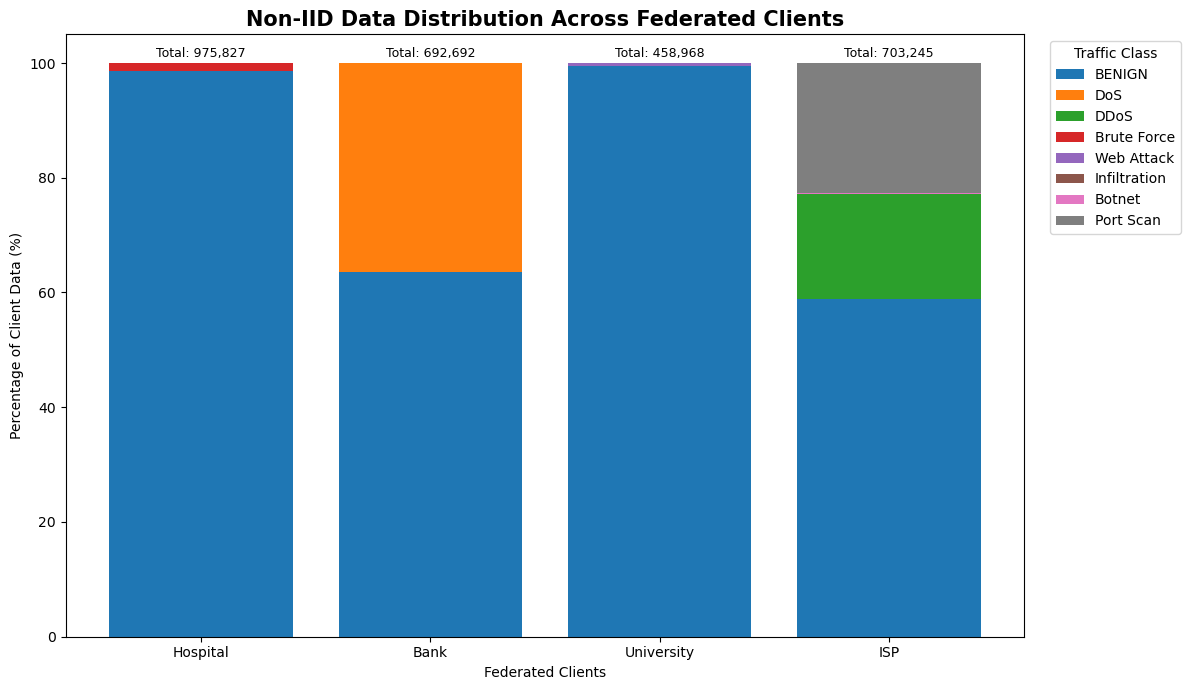

Figure saved successfully: ../docs/figures/day11_client_distribution.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

clients = distribution_df["Client"].tolist()

# Get percentages
benign = distribution_df["BENIGN (%)"].values
dos = distribution_df["DoS (%)"].values
ddos = distribution_df["DDoS (%)"].values
brute_force = distribution_df["Brute Force (%)"].values
web_attack = distribution_df["Web Attack (%)"].values
infiltration = distribution_df["Infiltration (%)"].values
botnet = distribution_df["Botnet (%)"].values
port_scan = distribution_df["Port Scan (%)"].values

x = np.arange(len(clients))

plt.figure(figsize=(12, 7))

bottom = np.zeros(len(clients))

categories_to_plot = [
    ("BENIGN", benign),
    ("DoS", dos),
    ("DDoS", ddos),
    ("Brute Force", brute_force),
    ("Web Attack", web_attack),
    ("Infiltration", infiltration),
    ("Botnet", botnet),
    ("Port Scan", port_scan)
]

for name, values in categories_to_plot:
    plt.bar(
        x,
        values,
        bottom=bottom,
        label=name
    )
    bottom += values

plt.xticks(x, clients)
plt.ylabel("Percentage of Client Data (%)")
plt.xlabel("Federated Clients")

plt.title(
    "Non-IID Data Distribution Across Federated Clients",
    fontsize=15,
    fontweight="bold"
)

plt.ylim(0, 105)
plt.legend(
    title="Traffic Class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Add total record count above each client
for i, total in enumerate(distribution_df["Total Records"]):
    plt.text(
        i,
        101,
        f"Total: {total:,}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

# Save figure
output_path = "../docs/figures/day11_client_distribution.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved successfully: {output_path}")

In [14]:
distribution_df.to_csv(
    "../docs/day11_client_distribution.csv",
    index=False
)

print("Updated Day 11 distribution table saved successfully.")

Updated Day 11 distribution table saved successfully.
